In [10]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
import pandas as pd
import numpy as np

import time
from datetime import datetime, timedelta
import os
import numpy as np
import pandas as pd
import requests


from web3 import Web3

from dotenv import load_dotenv
load_dotenv()

True

# EDA: Динамика комиссий Ethereum (апрель 2025 — апрель 2026)

In [2]:
plt.rcParams.update({
    "figure.facecolor": "#0d1117",
    "axes.facecolor":   "#0d1117",
    "axes.edgecolor":   "#30363d",
    "axes.labelcolor":  "#c9d1d9",
    "text.color":       "#c9d1d9",
    "xtick.color":      "#8b949e",
    "ytick.color":      "#8b949e",
    "grid.color":       "#21262d",
    "grid.linewidth":   0.6,
    "font.family":      "DejaVu Sans",
    "font.size":        11,
    "axes.titlesize":   13,
    "axes.titleweight": "bold",
})

C_BASE  = "#0098AF"   # teal  — base fee
C_PRIO  = "#355CA8"   # blue  — priority fee
C_ETH   = "#f0b429"   # amber — ETH price
C_FILL  = "#0098AF22"


prio_df = pd.read_csv(
    "data/priority_with_price_until_april.csv",
    usecols=["timestamp", "base_fee_per_gas", "priority_p50", "last_eth_price"],
    parse_dates=["timestamp"],
)
prio_df["base_gwei"] = prio_df["base_fee_per_gas"] / 1e9
prio_df["prio_gwei"] = prio_df["priority_p50"]      / 1e9
prio_df = prio_df.sort_values("timestamp").set_index("timestamp")


daily = prio_df[["base_gwei", "prio_gwei", "last_eth_price"]].resample("D").median()
daily["base_roll7"]  = daily["base_gwei"].rolling(7,  center=True).mean()
daily["base_roll30"] = daily["base_gwei"].rolling(30, center=True).mean()
daily["prio_roll7"]  = daily["prio_gwei"].rolling(7,  center=True).mean()



In [4]:
print(f"Строк (блоков): {len(prio_df):,}")
print(f"Период: {prio_df.index.min().date()} → {prio_df.index.max().date()}")
print(f"\nBase fee — макс: {daily.base_gwei.max():.2f} Gwei, мин: {daily.base_gwei.min():.3f} Gwei")
print(f"Priority (p50) — макс: {daily.prio_gwei.max():.3f} Gwei, мин: {daily.prio_gwei.min():.4f} Gwei")

Строк (блоков): 2,616,616
Период: 2025-04-15 → 2026-04-15

Base fee — макс: 4.54 Gwei, мин: 0.024 Gwei
Priority (p50) — макс: 1.000 Gwei, мин: 0.0014 Gwei


## 1. Долгосрочный тренд: base fee и priority fee за год

In [11]:
plt.style.use("default")

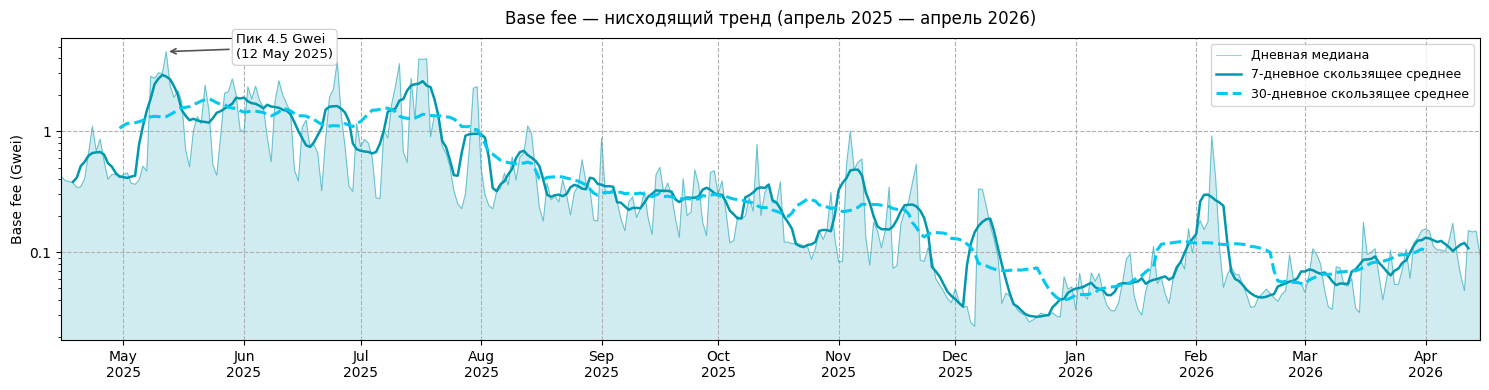

In [21]:
DATE_FMT_ARGS = dict(
    major_locator=mdates.MonthLocator(),
    major_formatter=mdates.DateFormatter("%b\n%Y"),
)

def _set_date_axis(ax):
    ax.xaxis.set_major_locator(DATE_FMT_ARGS["major_locator"])
    ax.xaxis.set_major_formatter(DATE_FMT_ARGS["major_formatter"])
    ax.set_xlim(daily.index[0], daily.index[-1])

# Base fee 
fig, ax = plt.subplots(figsize=(15, 4))

ax.fill_between(daily.index, daily["base_gwei"], alpha=0.18, color=C_BASE)
ax.plot(daily.index, daily["base_gwei"],   color=C_BASE,    lw=0.6, alpha=0.5, label="Дневная медиана")
ax.plot(daily.index, daily["base_roll7"],  color=C_BASE,    lw=1.8, label="7-дневное скользящее среднее")
ax.plot(daily.index, daily["base_roll30"], color="#00c8ef", lw=2.2, ls="--", label="30-дневное скользящее среднее")

peak_d = daily["base_gwei"].idxmax()
peak_v = daily["base_gwei"].max()
ax.annotate(
    f"Пик {peak_v:.1f} Gwei\n({peak_d.strftime('%d %b %Y')})",
    xy=(peak_d, peak_v),
    xytext=(peak_d + pd.Timedelta(days=18), peak_v * 0.88),
    arrowprops=dict(arrowstyle="->", color="#555", lw=1.2),
    fontsize=9.5,
    bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="#ccc", lw=0.8),
)

ax.set_title("Base fee — нисходящий тренд (апрель 2025 — апрель 2026)", pad=10)
ax.set_ylabel("Base fee (Gwei)")
ax.set_yscale("log")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:g}"))
ax.legend(loc="upper right", fontsize=9)
ax.grid(True, axis="both", ls="--")
_set_date_axis(ax)
plt.tight_layout()
plt.show()

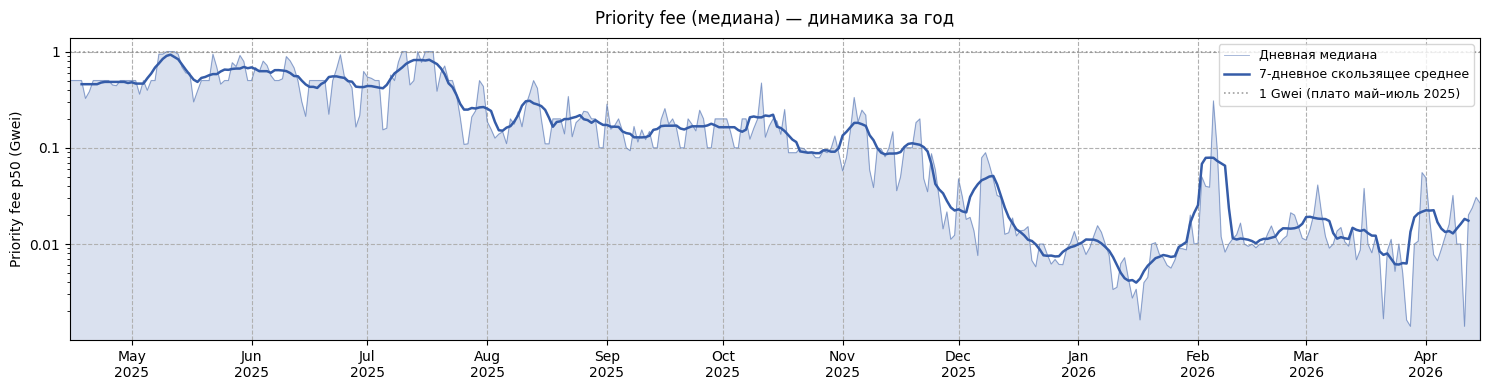

In [28]:
# График 2: Priority fee
fig, ax = plt.subplots(figsize=(15, 4))

ax.fill_between(daily.index, daily["prio_gwei"], alpha=0.18, color=C_PRIO)
ax.plot(daily.index, daily["prio_gwei"],  color=C_PRIO, lw=0.6, alpha=0.5, label="Дневная медиана")
ax.plot(daily.index, daily["prio_roll7"], color=C_PRIO, lw=1.8, label="7-дневное скользящее среднее")
ax.axhline(1.0, ls=":", color="#888", lw=1.2, alpha=0.8, label="1 Gwei (плато май–июль 2025)")

ax.set_title("Priority fee (медиана) — динамика за год", pad=10)
ax.set_ylabel("Priority fee p50 (Gwei)")
ax.set_yscale("log")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:g}"))
ax.legend(loc="upper right", fontsize=9)
ax.grid(True, axis="both", ls="--")
_set_date_axis(ax)
plt.tight_layout()
plt.show()

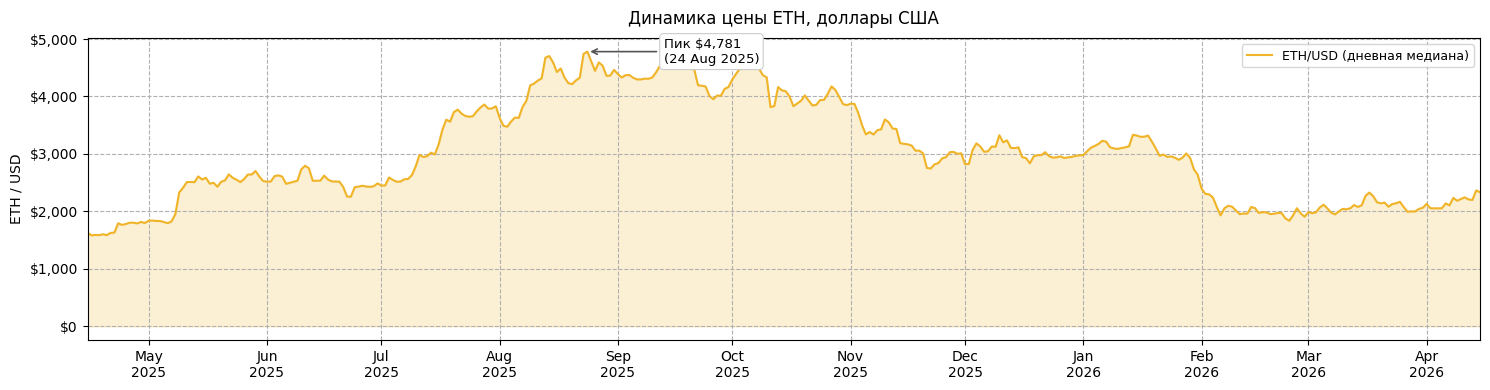

In [20]:
# Цена ETH
fig, ax = plt.subplots(figsize=(15, 4))

ax.fill_between(daily.index, daily["last_eth_price"], alpha=0.20, color=C_ETH)
ax.plot(daily.index, daily["last_eth_price"], color=C_ETH, lw=1.5, label="ETH/USD (дневная медиана)")

eth_peak_d = daily["last_eth_price"].idxmax()
eth_peak_v = daily["last_eth_price"].max()
ax.annotate(
    f"Пик ${eth_peak_v:,.0f}\n({eth_peak_d.strftime('%d %b %Y')})",
    xy=(eth_peak_d, eth_peak_v),
    xytext=(eth_peak_d + pd.Timedelta(days=20), eth_peak_v * 0.96),
    arrowprops=dict(arrowstyle="->", color="#555", lw=1.2),
    fontsize=9.5,
    bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="#ccc", lw=0.8),
)

ax.set_title("Динамика цены ETH, доллары США", pad=10)
ax.set_ylabel("ETH / USD")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
ax.legend(loc="upper right", fontsize=9)
ax.grid(True, axis="both", ls="--")
_set_date_axis(ax)
plt.tight_layout()
plt.show()

## 2. Сезонность: суточный и недельный цикл

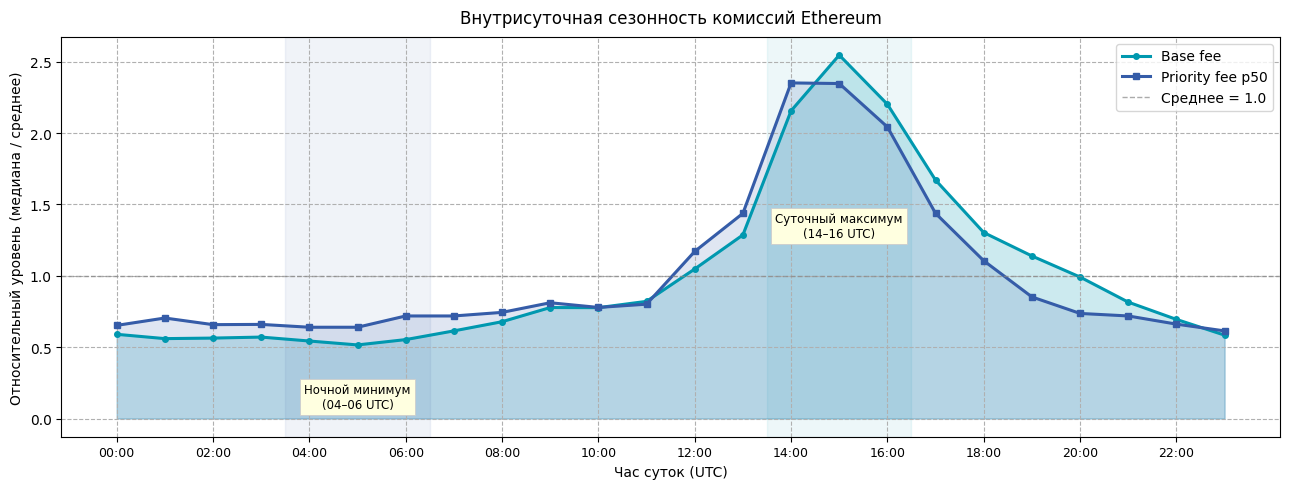

In [27]:
prio_df["hour"] = prio_df.index.hour
prio_df["dow"]  = prio_df.index.dayofweek   # 0=Пн … 6=Вс

hourly_med = prio_df.groupby("hour")[["base_gwei", "prio_gwei"]].median()
dow_med    = prio_df.groupby("dow")[["base_gwei", "prio_gwei"]].median()
dow_labels = ["Пн", "Вт", "Ср", "Чт", "Пт", "Сб", "Вс"]

# Нормируем: доля от среднесуточного (показывает относительное отклонение)
hourly_norm = hourly_med.div(hourly_med.mean())
dow_norm    = dow_med.div(dow_med.mean())

# График 1: Суточный цикл
fig, ax = plt.subplots(figsize=(13, 5))

x = hourly_norm.index
ax.fill_between(x, hourly_norm["base_gwei"], alpha=0.20, color=C_BASE)
ax.plot(x, hourly_norm["base_gwei"], color=C_BASE, lw=2.2, marker="o", ms=4, label="Base fee")
ax.fill_between(x, hourly_norm["prio_gwei"], alpha=0.15, color=C_PRIO)
ax.plot(x, hourly_norm["prio_gwei"], color=C_PRIO, lw=2.2, marker="s", ms=4, label="Priority fee p50")
ax.axhline(1.0, ls="--", color="#888", lw=1.0, alpha=0.7, label="Среднее = 1.0")

ax.axvspan(13.5, 16.5, alpha=0.07, color=C_BASE)
ax.text(15, hourly_norm["base_gwei"].max() * 0.5,
        "Суточный максимум\n(14–16 UTC)", ha="center", fontsize=8.5,
        bbox=dict(fc="lightyellow", ec="#ccc", lw=0.6, pad=3))

ax.axvspan(3.5, 6.5, alpha=0.07, color=C_PRIO)
ax.text(5, hourly_norm["base_gwei"].min() * 0.14,
        "Ночной минимум\n(04–06 UTC)", ha="center", fontsize=8.5,
        bbox=dict(fc="lightyellow", ec="#ccc", lw=0.6, pad=3))

ax.set_title("Внутрисуточная сезонность комиссий Ethereum", pad=10)
ax.set_xlabel("Час суток (UTC)")
ax.set_ylabel("Относительный уровень (медиана / среднее)")
ax.set_xticks(range(0, 24, 2))
ax.set_xticklabels([f"{h:02d}:00" for h in range(0, 24, 2)], fontsize=9)
ax.legend(fontsize=10)
ax.grid(True, ls="--")
plt.tight_layout()
plt.show()

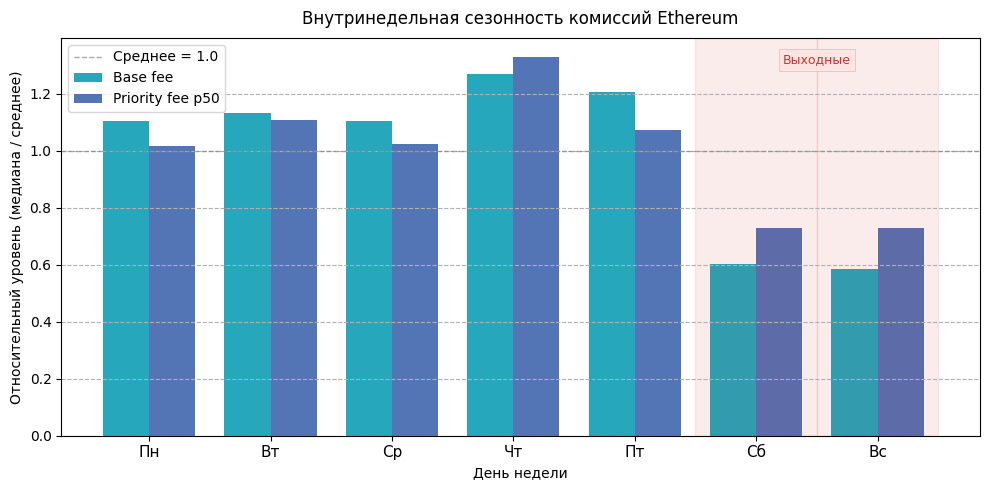

In [17]:
# Недельный цикл 
fig, ax = plt.subplots(figsize=(10, 5))

x2 = np.arange(7)
width = 0.38
ax.bar(x2 - width/2, dow_norm["base_gwei"], width, color=C_BASE, alpha=0.85, label="Base fee")
ax.bar(x2 + width/2, dow_norm["prio_gwei"], width, color=C_PRIO, alpha=0.85, label="Priority fee p50")
ax.axhline(1.0, ls="--", color="#888", lw=1.0, alpha=0.7, label="Среднее = 1.0")

for xi in [5, 6]:
    ax.axvspan(xi - 0.5, xi + 0.5, alpha=0.08, color="#D80F16")
ax.text(5.5, dow_norm["base_gwei"].max() * 1.03,
        "Выходные", ha="center", fontsize=9, color="#cc3333",
        bbox=dict(fc="mistyrose", ec="#ccc", lw=0.6, pad=3))

ax.set_title("Внутринедельная сезонность комиссий Ethereum", pad=10)
ax.set_xlabel("День недели")
ax.set_ylabel("Относительный уровень (медиана / среднее)")
ax.set_xticks(x2)
ax.set_xticklabels(dow_labels, fontsize=11)
ax.legend(fontsize=10)
ax.grid(True, axis="y", ls="--")
plt.tight_layout()
plt.show()